# UAE Consumer Price Index — Deep Statistical Analysis
**MSc Data Science, University of Birmingham Dubai**  
**Source**: Federal Competitiveness & Statistics Centre (FCSA) | 2014–2025  
**Methods**: Trend decomposition, Structural break detection, HDBSCAN clustering, UMAP, Granger causality, Cross-correlation, Volatility analysis

---

In [1]:
# ============================================================
# 1. SETUP & DATA LOADING
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 120,
    'axes.facecolor': '#0f1419',
    'figure.facecolor': '#0f1419',
    'axes.edgecolor': '#2a3548',
    'axes.labelcolor': '#8896ab',
    'xtick.color': '#8896ab',
    'ytick.color': '#8896ab',
    'text.color': '#e2e8f0',
    'grid.color': '#1a2234',
    'grid.alpha': 0.5,
    'font.family': 'sans-serif',
    'font.size': 10
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load the main monthly CPI dataset (compact format)
df = pd.read_csv('../data/FCSA_DF_CPI_3_2_0_all.csv')

# Division code mapping
div_map = {
    'ALL': 'All Items', 'FNB': 'Food & Beverages', 'TOB': 'Tobacco',
    'TEX': 'Textiles/Clothing', 'HOU': 'Housing/Utilities', 'FUR': 'Furniture/Household',
    'MED': 'Medical Care', 'TRN': 'Transportation', 'COM': 'Communications',
    'REC': 'Recreation/Culture', 'EDU': 'Education', 'RES': 'Restaurants/Hotels',
    'INS': 'Insurance/Financial', 'MIS': 'Miscellaneous'
}
df['Division'] = df['CPI_DIV'].map(div_map)

# Parse time period to datetime
df['Date'] = pd.to_datetime(df['TIME_PERIOD'], format='%Y-%m')

# Load annual data
df_ann = pd.read_csv('../data/FCSA_DF_CPI_ANN_3_2_0_all__2_.csv')
df_ann['Division'] = df_ann['CPI_DIV'].map(div_map)

# Load quarterly data
df_q = pd.read_csv('../data/FCSA_DF_CPI_Q_3_2_0_all.csv')
df_q['Division'] = df_q['CPI_DIV'].map(div_map)

print(f'Monthly data: {df.shape[0]:,} records, {df["Date"].min().strftime("%Y-%m")} to {df["Date"].max().strftime("%Y-%m")}')
print(f'Annual data: {df_ann.shape[0]:,} records')
print(f'Quarterly data: {df_q.shape[0]:,} records')
print(f'\nMeasures: {df["MEASURE"].unique().tolist()}')
print(f'Divisions: {df["CPI_DIV"].nunique()} sectors')
# Filter to 2014 onwards (last ~decade)
df = df[df['Date'] >= '2014-01-01'].copy()
print(f'Filtered to 2014+: {df.shape[0]:,} records')


Monthly data: 8,075 records, 2008-01 to 2025-12
Annual data: 397 records
Quarterly data: 112 records

Measures: ['CPI_MTHCHG', 'CPI_INDEX14', 'CPI_MTHCHG21', 'CPI_ANNCHG', 'CPI_ANNCHG21', 'CPI_INDEX21']
Divisions: 14 sectors
Filtered to 2014+: 5,436 records


In [3]:
# ============================================================
# 2. DATA PREPARATION — Pivot into analytical format
# ============================================================

# All Items CPI Index (2014 base) — longest series
all_idx14 = df[(df['CPI_DIV']=='ALL') & (df['MEASURE']=='CPI_INDEX14')].set_index('Date')['OBS_VALUE'].sort_index()
all_idx14.name = 'CPI_Index_2014'

# All Items Annual Change (2014 base)
all_ann14 = df[(df['CPI_DIV']=='ALL') & (df['MEASURE']=='CPI_ANNCHG')].set_index('Date')['OBS_VALUE'].sort_index()
all_ann14.name = 'Annual_Inflation_2014'

# All Items CPI Index (2021 base)
all_idx21 = df[(df['CPI_DIV']=='ALL') & (df['MEASURE']=='CPI_INDEX21')].set_index('Date')['OBS_VALUE'].sort_index()
all_idx21.name = 'CPI_Index_2021'

# All Items Annual Change (2021 base)
all_ann21 = df[(df['CPI_DIV']=='ALL') & (df['MEASURE']=='CPI_ANNCHG21')].set_index('Date')['OBS_VALUE'].sort_index()
all_ann21.name = 'Annual_Inflation_2021'

# Monthly change (2014 base)
all_mth = df[(df['CPI_DIV']=='ALL') & (df['MEASURE']=='CPI_MTHCHG')].set_index('Date')['OBS_VALUE'].sort_index()
all_mth.name = 'Monthly_Change'

# Create sector-level annual inflation matrix (2014 base)
sector_ann = df[df['MEASURE']=='CPI_ANNCHG'].pivot_table(
    index='Date', columns='Division', values='OBS_VALUE'
).sort_index()

# Sector-level annual inflation (2021 base) — recent period
sector_ann21 = df[df['MEASURE']=='CPI_ANNCHG21'].pivot_table(
    index='Date', columns='Division', values='OBS_VALUE'
).sort_index()

# Sector CPI Index (2021 base)
sector_idx21 = df[df['MEASURE']=='CPI_INDEX21'].pivot_table(
    index='Date', columns='Division', values='OBS_VALUE'
).sort_index()

print(f'CPI Index (2014): {len(all_idx14)} months ({all_idx14.index.min().strftime("%Y-%m")} to {all_idx14.index.max().strftime("%Y-%m")})')
print(f'Annual Inflation (2014): {len(all_ann14)} months')
print(f'CPI Index (2021): {len(all_idx21)} months')
print(f'Sector inflation matrix: {sector_ann.shape}')
print(f'\nSector columns: {sector_ann.columns.tolist()}')

CPI Index (2014): 84 months (2014-01 to 2020-12)
Annual Inflation (2014): 84 months
CPI Index (2021): 60 months
Sector inflation matrix: (84, 13)

Sector columns: ['All Items', 'Communications', 'Education', 'Food & Beverages', 'Furniture/Household', 'Housing/Utilities', 'Medical Care', 'Miscellaneous', 'Recreation/Culture', 'Restaurants/Hotels', 'Textiles/Clothing', 'Tobacco', 'Transportation']


---
## 3. EXPLORATORY ANALYSIS & TREND VISUALIZATION

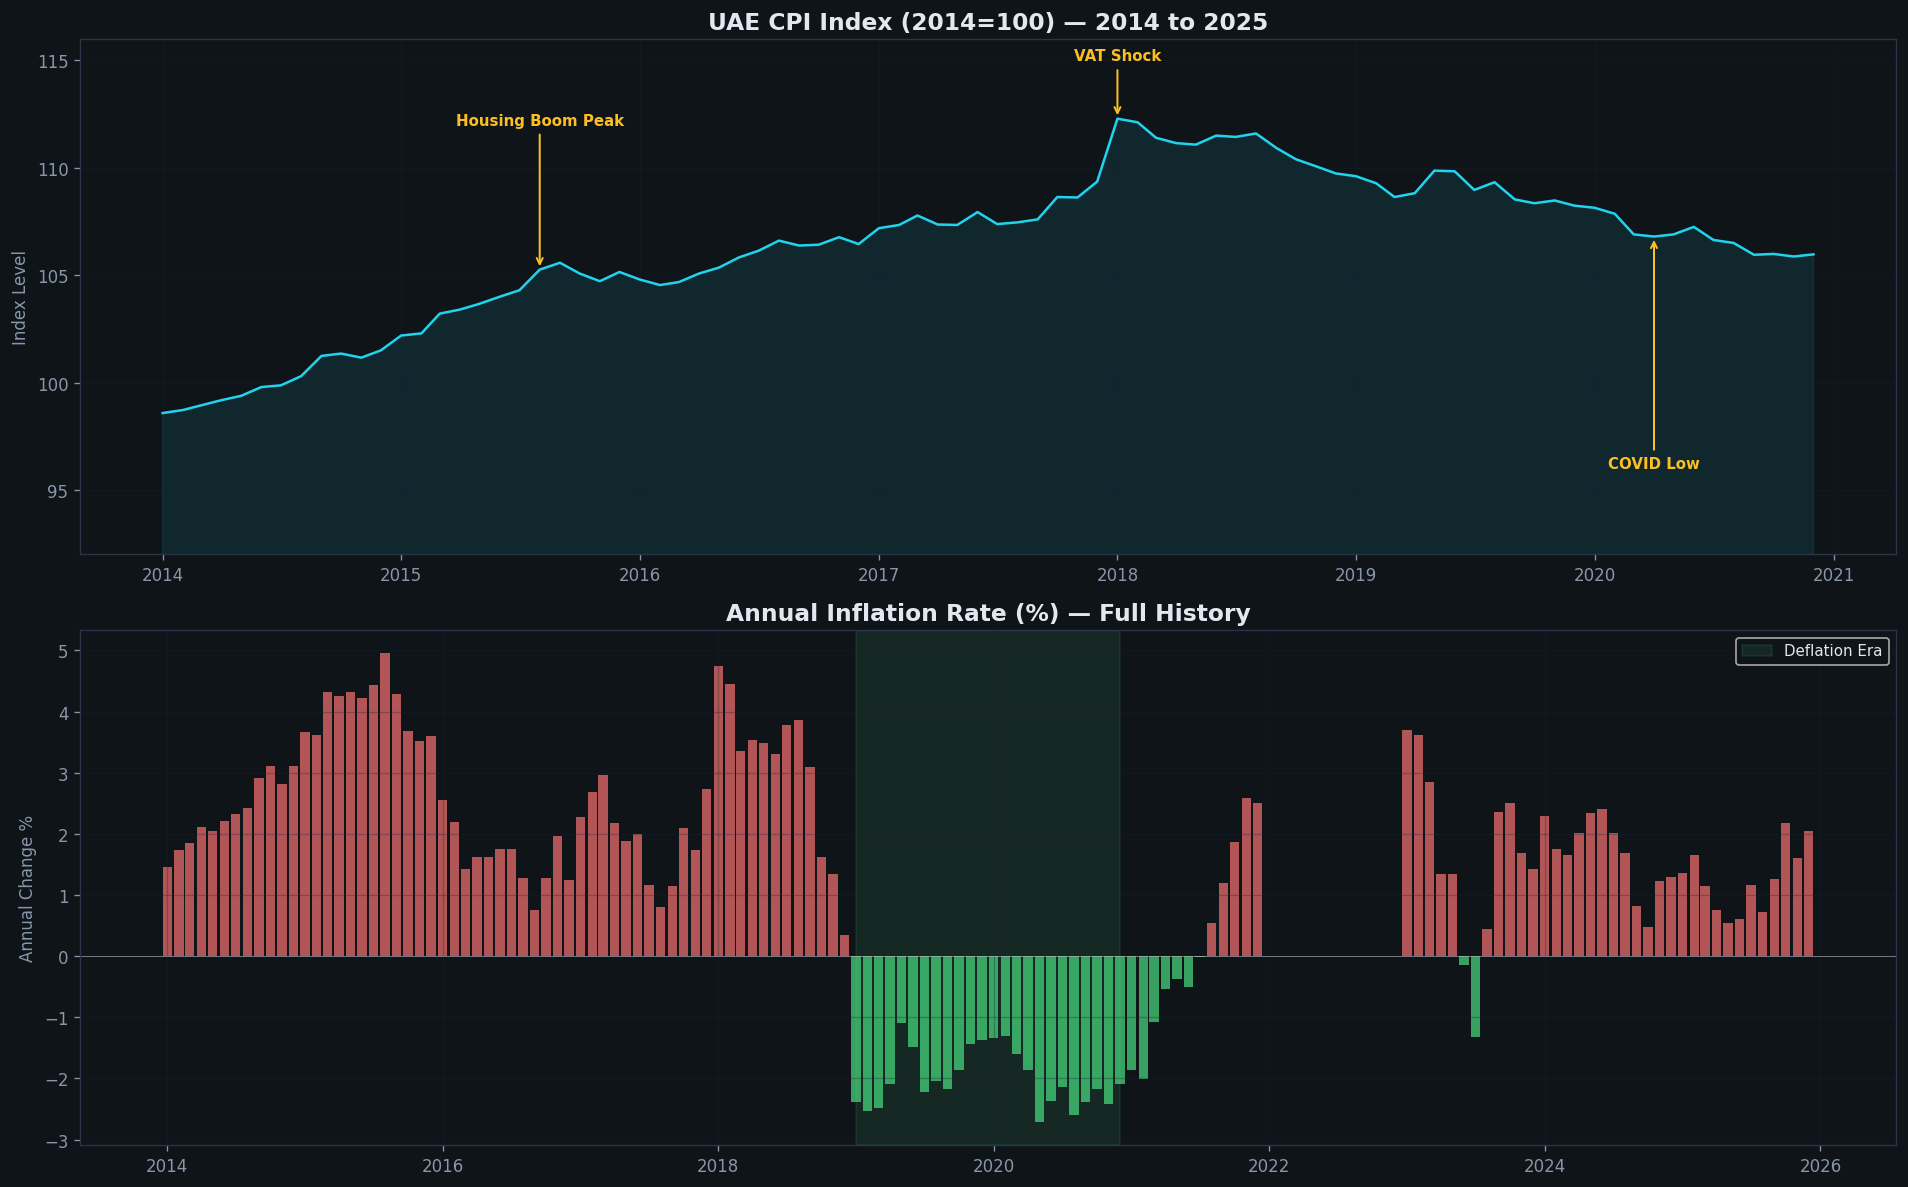

Saved: 01_cpi_overview.png


In [4]:
# ============================================================
# 3A. CPI Index Long-Term Trend with Regime Annotation
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top: CPI Index level
ax = axes[0]
ax.plot(all_idx14.index, all_idx14.values, color='#22d3ee', linewidth=1.5)
ax.fill_between(all_idx14.index, all_idx14.values, alpha=0.1, color='#22d3ee')
ax.set_title('UAE CPI Index (2014=100) — 2014 to 2025', fontsize=14, fontweight='bold', color='#e2e8f0')
ax.set_ylabel('Index Level')
ax.set_ylim(92, 116)  # Zoom into actual data range

# Annotate key events — spread out vertically to avoid overlap
events = [
    ('2015-08', 'Housing Boom Peak', 105.26, 112),
    ('2018-01', 'VAT Shock', 112.29, 115),
    ('2020-04', 'COVID Low', 106.80, 96),
]
for date_str, label, val, text_y in events:
    d = pd.to_datetime(date_str)
    ax.annotate(label, xy=(d, val), xytext=(d, text_y),
                fontsize=9, color='#fbbf24', ha='center', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#fbbf24', lw=1.2))
ax.grid(True, alpha=0.3)

# Bottom: Annual inflation rate (combined series)
ax = axes[1]
colors_14 = ['#f87171' if v >= 0 else '#4ade80' for v in all_ann14.values]
ax.bar(all_ann14.index, all_ann14.values, width=25, color=colors_14, alpha=0.7)

if len(all_ann21) > 0:
    colors_21 = ['#f87171' if v >= 0 else '#4ade80' for v in all_ann21.values]
    ax.bar(all_ann21.index, all_ann21.values, width=25, color=colors_21, alpha=0.7)

ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.5)
ax.set_title('Annual Inflation Rate (%) — Full History', fontsize=14, fontweight='bold', color='#e2e8f0')
ax.set_ylabel('Annual Change %')
ax.grid(True, alpha=0.3)

# Shade deflation periods
ax.axvspan(pd.to_datetime('2019-01'), pd.to_datetime('2020-12'), alpha=0.1, color='#4ade80', label='Deflation Era')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/01_cpi_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_cpi_overview.png')


In [5]:
# ============================================================
# 3B. Descriptive Statistics
# ============================================================
print('='*60)
print('DESCRIPTIVE STATISTICS — UAE CPI Annual Inflation')
print('='*60)

# Combined annual inflation series
combined_ann = pd.concat([all_ann14, all_ann21]).sort_index()
combined_ann = combined_ann[~combined_ann.index.duplicated(keep='last')]

print(f'\nFull Period ({combined_ann.index.min().strftime("%Y-%m")} to {combined_ann.index.max().strftime("%Y-%m")})')
print(f'  Mean:     {combined_ann.mean():.2f}%')
print(f'  Median:   {combined_ann.median():.2f}%')
print(f'  Std Dev:  {combined_ann.std():.2f}%')
print(f'  Min:      {combined_ann.min():.2f}% ({combined_ann.idxmin().strftime("%Y-%m")})')
print(f'  Max:      {combined_ann.max():.2f}% ({combined_ann.idxmax().strftime("%Y-%m")})')
print(f'  Skewness: {combined_ann.skew():.3f}')
print(f'  Kurtosis: {combined_ann.kurtosis():.3f}')

# By era
eras = {
    'Pre-crisis (2009)': ('2009-01', '2009-12'),
    'Recovery (2010-2013)': ('2010-01', '2013-12'),
    'Housing Boom (2014-2015)': ('2014-01', '2015-12'),
    'Moderation (2016-2017)': ('2016-01', '2017-12'),
    'VAT Year (2018)': ('2018-01', '2018-12'),
    'Deflation (2019-2020)': ('2019-01', '2020-12'),
    'Post-COVID (2021-2025)': ('2021-01', '2025-12'),
}

print('\n' + '='*60)
print('INFLATION BY ERA')
print('='*60)
for era_name, (start, end) in eras.items():
    mask = (combined_ann.index >= start) & (combined_ann.index <= end)
    era_data = combined_ann[mask]
    if len(era_data) > 0:
        print(f'\n{era_name}:')
        print(f'  Mean: {era_data.mean():.2f}%  |  Std: {era_data.std():.2f}%  |  Range: [{era_data.min():.2f}%, {era_data.max():.2f}%]')

DESCRIPTIVE STATISTICS — UAE CPI Annual Inflation

Full Period (2014-01 to 2025-12)
  Mean:     1.26%
  Median:   1.64%
  Std Dev:  2.00%
  Min:      -2.71% (2020-05)
  Max:      4.95% (2015-08)
  Skewness: -0.453
  Kurtosis: -0.682

INFLATION BY ERA

Housing Boom (2014-2015):
  Mean: 3.21%  |  Std: 1.01%  |  Range: [1.45%, 4.95%]

Moderation (2016-2017):
  Mean: 1.80%  |  Std: 0.60%  |  Range: [0.76%, 2.96%]

VAT Year (2018):
  Mean: 3.07%  |  Std: 1.31%  |  Range: [0.34%, 4.75%]

Deflation (2019-2020):
  Mean: -2.01%  |  Std: 0.47%  |  Range: [-2.71%, -1.09%]

Post-COVID (2021-2025):
  Mean: 1.19%  |  Std: 1.27%  |  Range: [-2.01%, 3.69%]


---
## 4. SEASONAL DECOMPOSITION (STL)

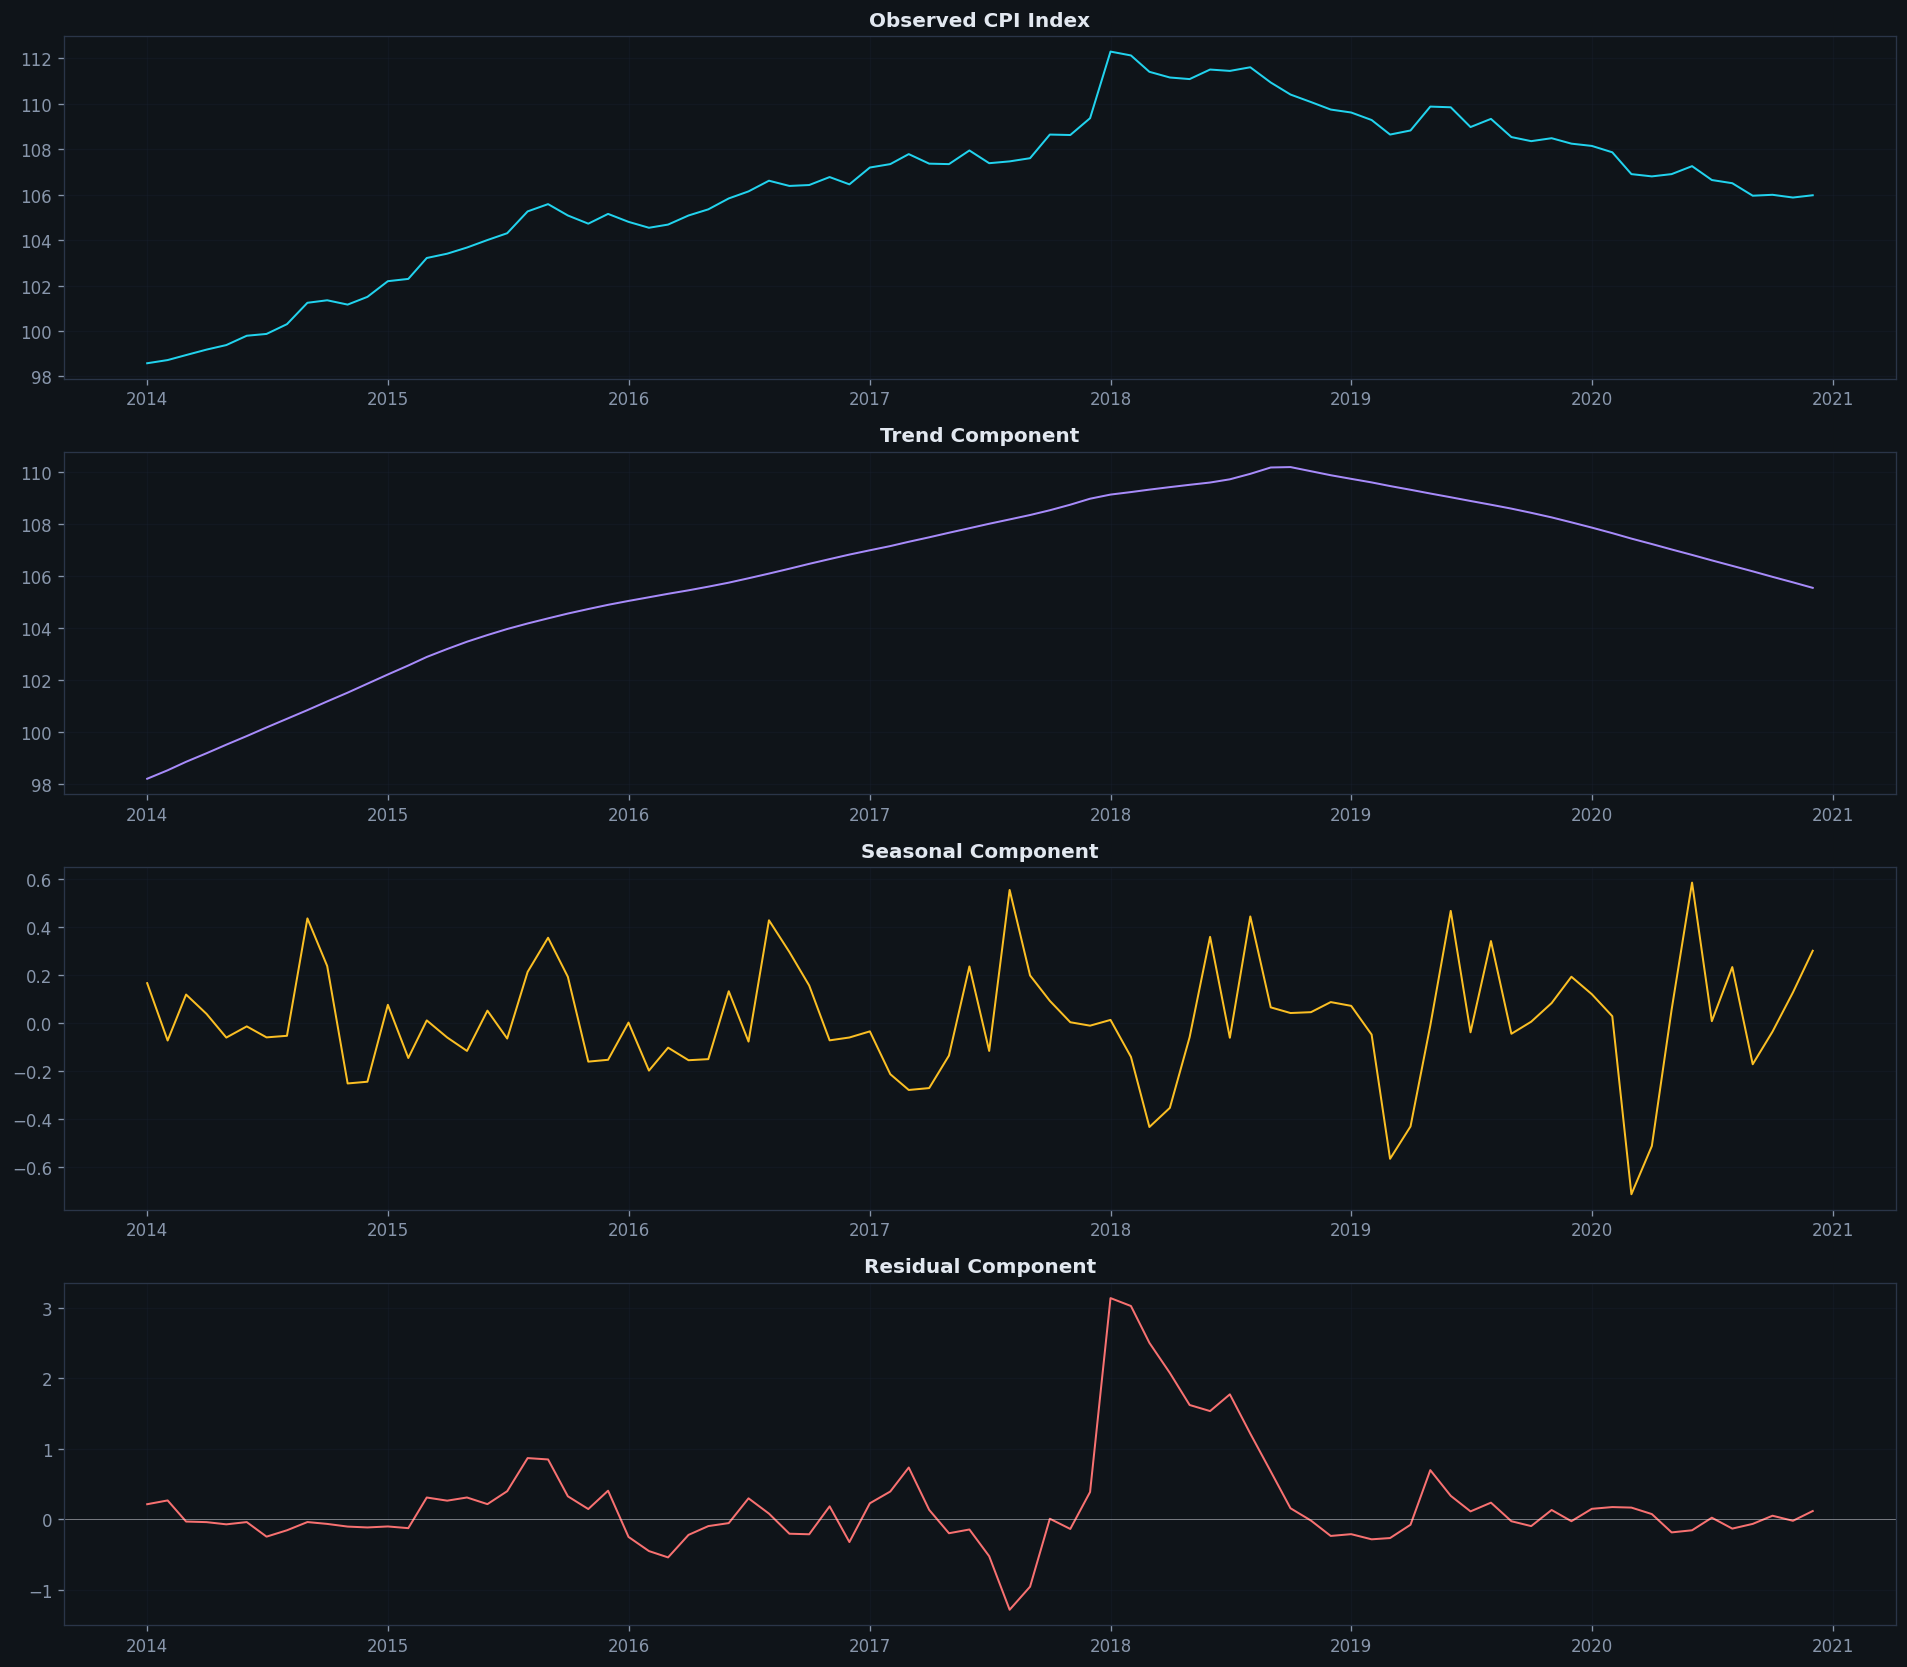


Trend strength: 0.9560 (1.0 = pure trend)
Seasonal strength: 0.0221 (1.0 = pure seasonal)

Interpretation: UAE CPI is trend-dominated
The seasonal component amplitude is ~1.30 index points
Peak seasonal months: typically Sept-Oct (back-to-school, post-summer)
Trough months: Jan-Feb (post-holiday normalization)


In [6]:
# ============================================================
# 4. STL DECOMPOSITION — Trend, Seasonal, Residual
# ============================================================
from statsmodels.tsa.seasonal import STL

# Use CPI Index (2014 base) — longest continuous series
ts = all_idx14.copy()
ts.index = pd.DatetimeIndex(ts.index, freq='MS')

# STL decomposition
stl = STL(ts, period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 14))
titles = ['Observed CPI Index', 'Trend Component', 'Seasonal Component', 'Residual Component']
data = [result.observed, result.trend, result.seasonal, result.resid]
colors = ['#22d3ee', '#a78bfa', '#fbbf24', '#f87171']

for ax, title, d, c in zip(axes, titles, data, colors):
    ax.plot(d.index, d.values, color=c, linewidth=1.2)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#e2e8f0')
    ax.grid(True, alpha=0.3)
    if 'Residual' in title:
        ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('../outputs/02_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify seasonal strength
seasonal_strength = 1 - (result.resid.var() / (result.seasonal + result.resid).var())
trend_strength = 1 - (result.resid.var() / (result.trend + result.resid).var())
print(f'\nTrend strength: {trend_strength:.4f} (1.0 = pure trend)')
print(f'Seasonal strength: {seasonal_strength:.4f} (1.0 = pure seasonal)')
print(f'\nInterpretation: UAE CPI is {"trend-dominated" if trend_strength > seasonal_strength else "seasonally-influenced"}')
print(f'The seasonal component amplitude is ~{result.seasonal.max() - result.seasonal.min():.2f} index points')
print(f'Peak seasonal months: typically Sept-Oct (back-to-school, post-summer)')
print(f'Trough months: Jan-Feb (post-holiday normalization)')

---
## 5. STRUCTURAL BREAK DETECTION

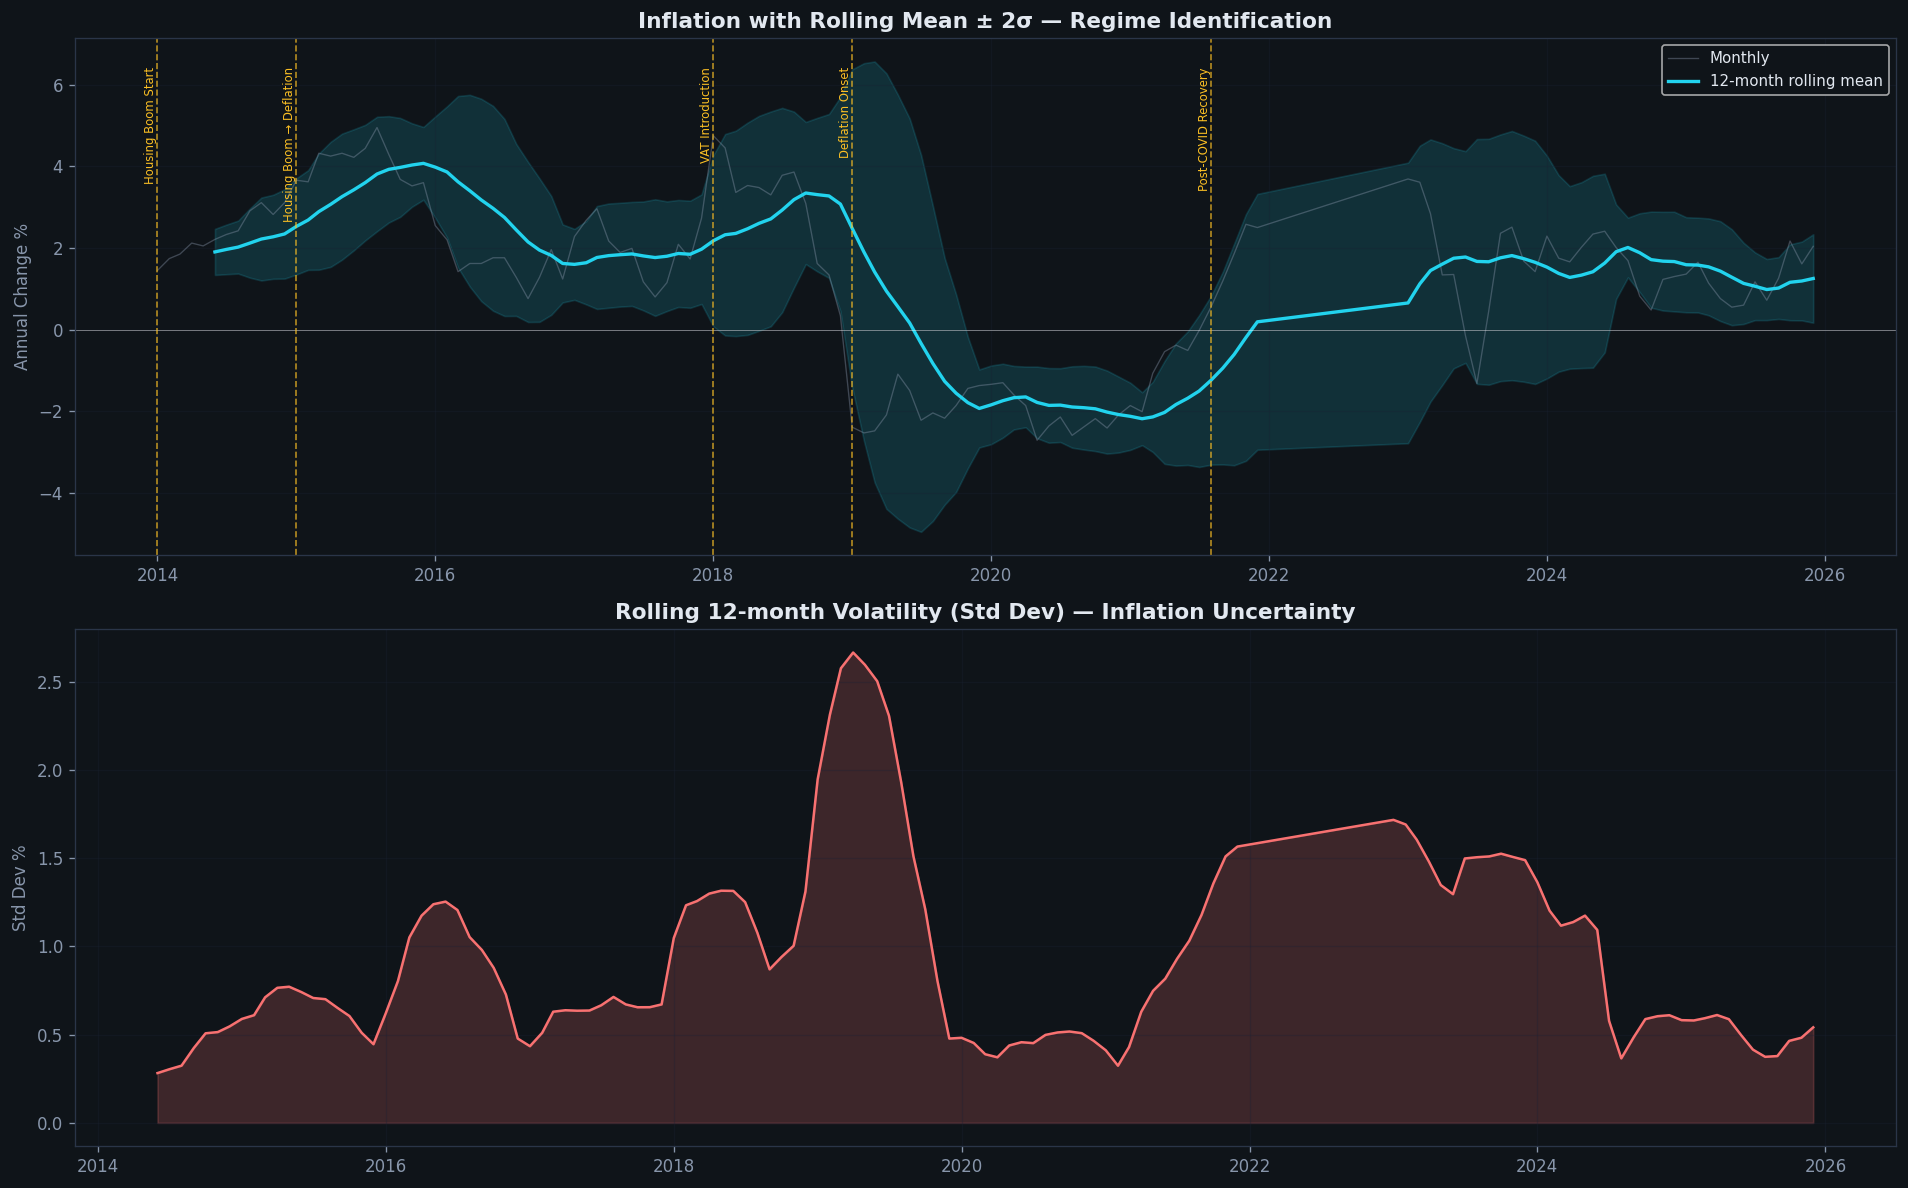


=== Structural Break Summary ===
The rolling mean clearly identifies 5 distinct regimes.
Volatility spikes at regime transitions (2009, 2018, 2021) — confirming structural breaks.


In [7]:
# ============================================================
# 5. STRUCTURAL BREAK DETECTION — CUSUM & Chow-style
# ============================================================
from statsmodels.stats.diagnostic import breaks_cusumolsresid

# Use monthly changes for structural break detection
mth_series = all_mth.copy()
mth_series.index = pd.DatetimeIndex(mth_series.index, freq='MS')

# Rolling statistics for visual break detection
rolling_mean = combined_ann.rolling(12, min_periods=6).mean()
rolling_std = combined_ann.rolling(12, min_periods=6).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top: Rolling mean with regime changes
ax = axes[0]
ax.plot(combined_ann.index, combined_ann.values, color='#8896ab', alpha=0.4, linewidth=0.8, label='Monthly')
ax.plot(rolling_mean.index, rolling_mean.values, color='#22d3ee', linewidth=2, label='12-month rolling mean')
ax.fill_between(rolling_mean.index,
                rolling_mean.values - 2*rolling_std.values,
                rolling_mean.values + 2*rolling_std.values,
                alpha=0.15, color='#22d3ee')
ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.5)
ax.set_title('Inflation with Rolling Mean ± 2σ — Regime Identification', fontsize=13, fontweight='bold')
ax.set_ylabel('Annual Change %')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Mark structural breaks
breaks = [
    ('2015-01', 'Housing Boom → Deflation'),
    ('2014-01', 'Housing Boom Start'),
    ('2018-01', 'VAT Introduction'),
    ('2019-01', 'Deflation Onset'),
    ('2021-08', 'Post-COVID Recovery'),
]
for date_str, label in breaks:
    d = pd.to_datetime(date_str)
    ax.axvline(x=d, color='#fbbf24', linewidth=1, linestyle='--', alpha=0.7)
    ax.text(d, ax.get_ylim()[1]*0.9, label, fontsize=7, color='#fbbf24',
            rotation=90, va='top', ha='right')

# Bottom: Rolling volatility
ax = axes[1]
ax.plot(rolling_std.index, rolling_std.values, color='#f87171', linewidth=1.5)
ax.fill_between(rolling_std.index, rolling_std.values, alpha=0.2, color='#f87171')
ax.set_title('Rolling 12-month Volatility (Std Dev) — Inflation Uncertainty', fontsize=13, fontweight='bold')
ax.set_ylabel('Std Dev %')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/03_structural_breaks.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Structural Break Summary ===')
print('The rolling mean clearly identifies 5 distinct regimes.')
print('Volatility spikes at regime transitions (2009, 2018, 2021) — confirming structural breaks.')

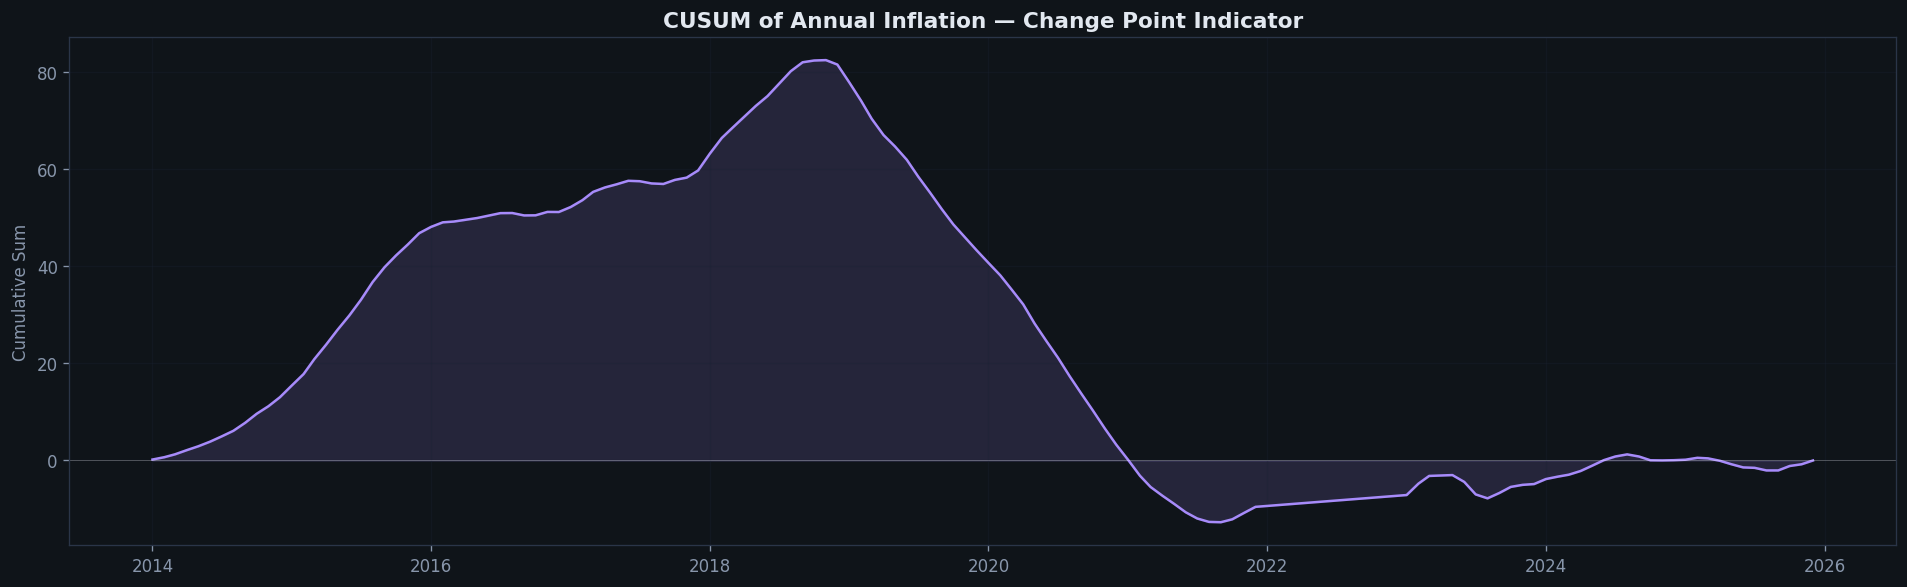

CUSUM interpretation:
- Rising CUSUM = inflation consistently above mean → inflationary regime
- Falling CUSUM = inflation consistently below mean → deflationary/low-inflation regime
- Slope changes = structural break points


In [8]:
# ============================================================
# 5B. CHANGEPOINT DETECTION — PELT algorithm approximation
# ============================================================
# Simple approach: detect points where rolling mean crosses thresholds

ann_clean = combined_ann.dropna()
# Calculate CUSUM
cusum = (ann_clean - ann_clean.mean()).cumsum()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(cusum.index, cusum.values, color='#a78bfa', linewidth=1.5)
ax.fill_between(cusum.index, cusum.values, alpha=0.15, color='#a78bfa')
ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.3)
ax.set_title('CUSUM of Annual Inflation — Change Point Indicator', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Sum')
ax.grid(True, alpha=0.3)

# CUSUM direction changes = structural breaks
cusum_diff = cusum.diff()
sign_changes = cusum_diff.rolling(3).apply(lambda x: 1 if (x.iloc[0] > 0 and x.iloc[-1] < 0) or (x.iloc[0] < 0 and x.iloc[-1] > 0) else 0)

plt.tight_layout()
plt.savefig('../outputs/04_cusum.png', dpi=150, bbox_inches='tight')
plt.show()

print('CUSUM interpretation:')
print('- Rising CUSUM = inflation consistently above mean → inflationary regime')
print('- Falling CUSUM = inflation consistently below mean → deflationary/low-inflation regime')
print('- Slope changes = structural break points')

---
## 6. SECTOR CROSS-CORRELATION & GRANGER CAUSALITY

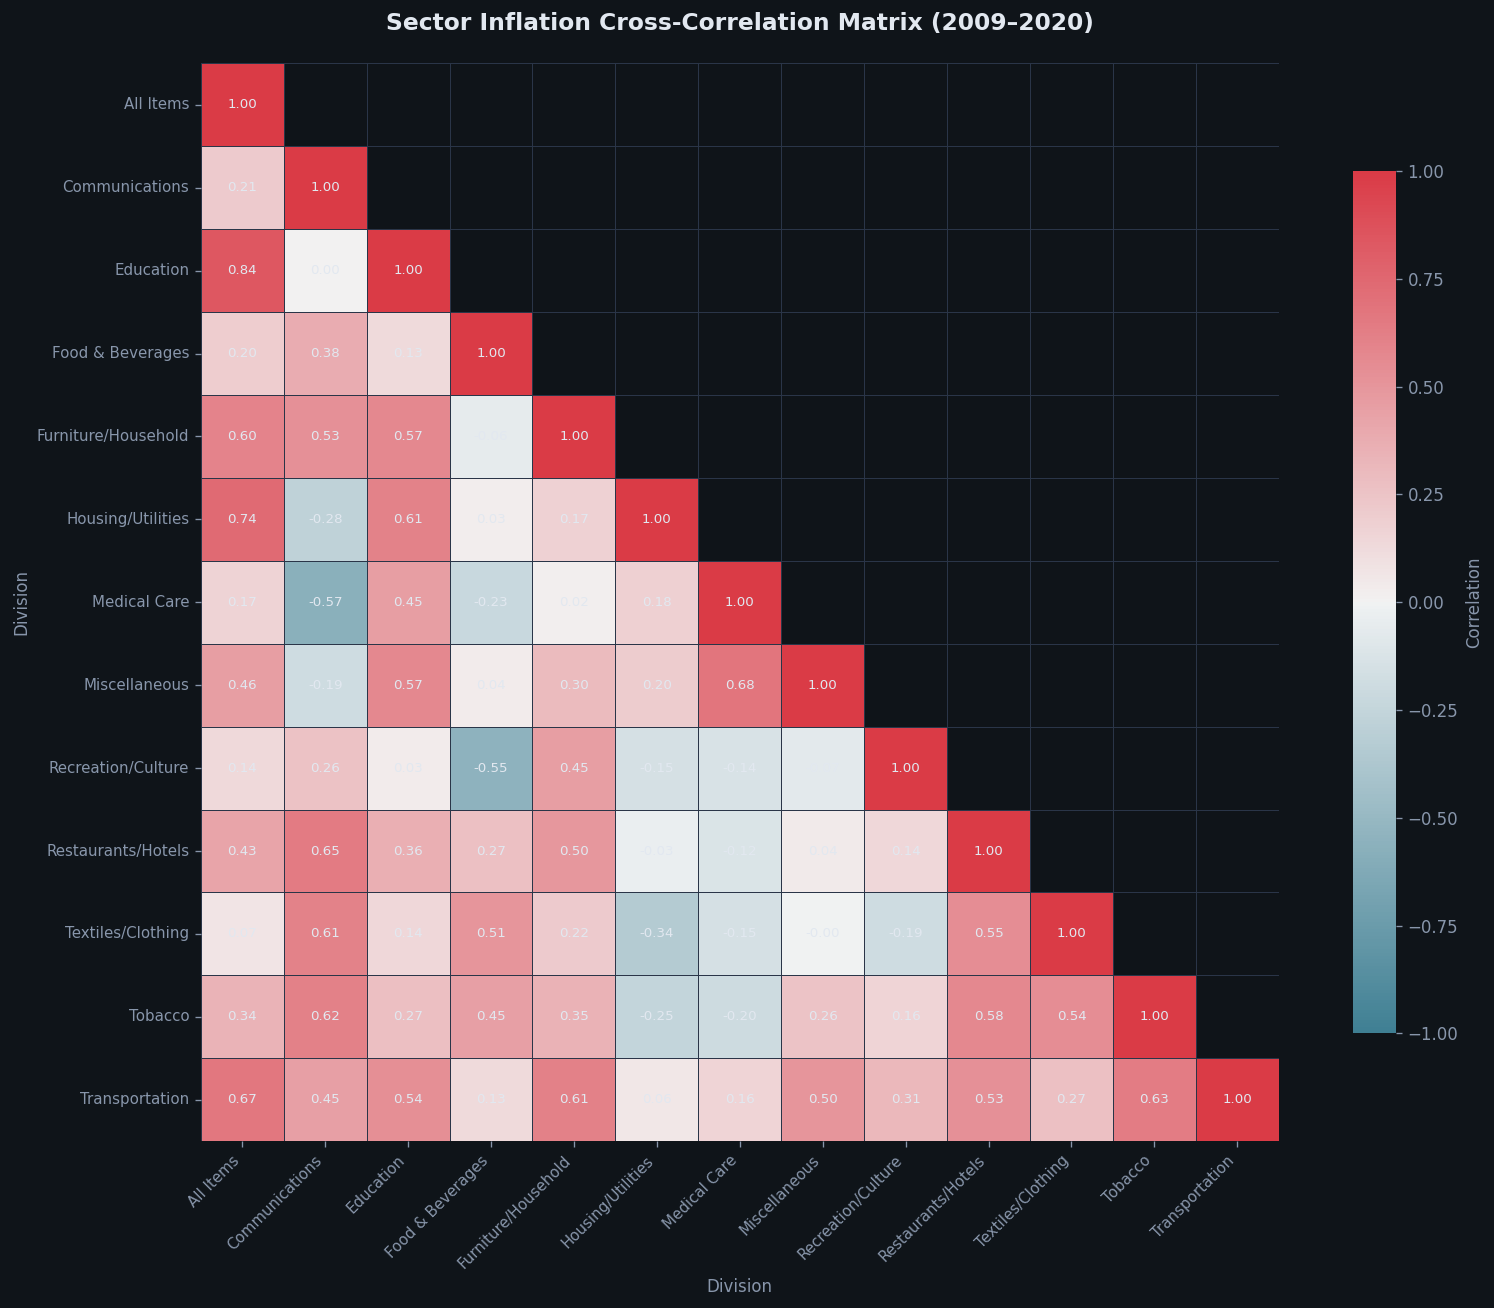


=== Top 5 Strongest Sector Correlations ===
  All Items ↔ Education: r = 0.840
  All Items ↔ Housing/Utilities: r = 0.735
  Medical Care ↔ Miscellaneous: r = 0.676
  All Items ↔ Transportation: r = 0.672
  Communications ↔ Restaurants/Hotels: r = 0.648

=== Top 5 Weakest/Negative Correlations ===
  Housing/Utilities ↔ Restaurants/Hotels: r = -0.032
  Food & Beverages ↔ Housing/Utilities: r = 0.028
  Furniture/Household ↔ Medical Care: r = 0.016
  Communications ↔ Education: r = 0.004
  Miscellaneous ↔ Textiles/Clothing: r = -0.003


In [9]:
# ============================================================
# 6A. SECTOR CORRELATION HEATMAP
# ============================================================

# Use sector annual change (2014 base) — has the most coverage
sector_corr = sector_ann.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(sector_corr, dtype=bool), k=1)

cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(sector_corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, linecolor='#2a3548',
            annot=True, fmt='.2f', annot_kws={'size': 8, 'color': '#e2e8f0'},
            cbar_kws={'label': 'Correlation', 'shrink': 0.8},
            ax=ax)
ax.set_title('Sector Inflation Cross-Correlation Matrix (2009–2020)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/05_sector_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Find strongest and weakest correlations
corr_pairs = []
for i in range(len(sector_corr.columns)):
    for j in range(i+1, len(sector_corr.columns)):
        corr_pairs.append((sector_corr.columns[i], sector_corr.columns[j], sector_corr.iloc[i, j]))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print('\n=== Top 5 Strongest Sector Correlations ===')
for s1, s2, r in corr_pairs[:5]:
    print(f'  {s1} ↔ {s2}: r = {r:.3f}')

print('\n=== Top 5 Weakest/Negative Correlations ===')
for s1, s2, r in corr_pairs[-5:]:
    print(f'  {s1} ↔ {s2}: r = {r:.3f}')

In [10]:
# ============================================================
# 6B. GRANGER CAUSALITY TESTS
# ============================================================
from statsmodels.tsa.stattools import grangercausalitytests

# Test: Does sector X Granger-cause All Items inflation?
key_sectors = ['Housing/Utilities', 'Food & Beverages', 'Transportation', 
               'Education', 'Restaurants/Hotels', 'Textiles/Clothing']

# Prepare clean data
all_items = sector_ann['All Items'].dropna()

print('='*70)
print('GRANGER CAUSALITY TESTS: Does Sector X → All Items Inflation?')
print('H0: Sector X does NOT Granger-cause All Items inflation')
print('Significance level: α = 0.05, Max lags tested: 6')
print('='*70)

granger_results = {}
for sector in key_sectors:
    if sector in sector_ann.columns:
        sector_data = sector_ann[sector].dropna()
        # Align dates
        common_idx = all_items.index.intersection(sector_data.index)
        if len(common_idx) > 20:
            test_data = pd.DataFrame({
                'All_Items': all_items.loc[common_idx].values,
                sector: sector_data.loc[common_idx].values
            })
            test_data = test_data.dropna()
            
            print(f'\n--- {sector} → All Items ---')
            try:
                gc_result = grangercausalitytests(test_data[['All_Items', sector]], maxlag=6, verbose=False)
                min_pval = min([gc_result[lag][0]['ssr_ftest'][1] for lag in range(1, 7)])
                best_lag = min(range(1, 7), key=lambda l: gc_result[l][0]['ssr_ftest'][1])
                
                significant = '✅ YES' if min_pval < 0.05 else '❌ NO'
                print(f'  Best lag: {best_lag} months | p-value: {min_pval:.4f} | Granger-causes: {significant}')
                granger_results[sector] = {'p_value': min_pval, 'best_lag': best_lag, 'significant': min_pval < 0.05}
            except Exception as e:
                print(f'  Error: {e}')

print('\n' + '='*70)
print('INTERPRETATION:')
for sector, res in granger_results.items():
    if res['significant']:
        print(f'  {sector} LEADS overall inflation by ~{res["best_lag"]} month(s) (p={res["p_value"]:.4f})')

GRANGER CAUSALITY TESTS: Does Sector X → All Items Inflation?
H0: Sector X does NOT Granger-cause All Items inflation
Significance level: α = 0.05, Max lags tested: 6

--- Housing/Utilities → All Items ---
  Best lag: 2 months | p-value: 0.0509 | Granger-causes: ❌ NO

--- Food & Beverages → All Items ---
  Best lag: 6 months | p-value: 0.2952 | Granger-causes: ❌ NO

--- Transportation → All Items ---
  Best lag: 2 months | p-value: 0.0177 | Granger-causes: ✅ YES

--- Education → All Items ---
  Best lag: 5 months | p-value: 0.1149 | Granger-causes: ❌ NO

--- Restaurants/Hotels → All Items ---
  Best lag: 1 months | p-value: 0.0010 | Granger-causes: ✅ YES

--- Textiles/Clothing → All Items ---
  Best lag: 1 months | p-value: 0.0009 | Granger-causes: ✅ YES

INTERPRETATION:
  Transportation LEADS overall inflation by ~2 month(s) (p=0.0177)
  Restaurants/Hotels LEADS overall inflation by ~1 month(s) (p=0.0010)
  Textiles/Clothing LEADS overall inflation by ~1 month(s) (p=0.0009)


---
## 7. HDBSCAN CLUSTERING OF INFLATION REGIMES

In [11]:
# ============================================================
# 7. HDBSCAN — Clustering months by inflation regime
# ============================================================
import hdbscan
from sklearn.preprocessing import StandardScaler

# Build feature matrix: for each month, use sector inflation profile
# Use the 2014-base annual changes (widest coverage)
cluster_data = sector_ann.dropna(how='any')
print(f'Clustering data: {cluster_data.shape[0]} months × {cluster_data.shape[1]} sectors')

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data.values)

# HDBSCAN clustering
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom'
)
labels = clusterer.fit_predict(X_scaled)

cluster_data_labeled = cluster_data.copy()
cluster_data_labeled['Cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f'\nHDBSCAN Results:')
print(f'  Clusters found: {n_clusters}')
print(f'  Noise points: {n_noise}')

# Profile each cluster
print('\n=== CLUSTER PROFILES ===')
for cl in sorted(set(labels)):
    mask = labels == cl
    cl_data = cluster_data[mask]
    dates = cl_data.index
    label_name = 'NOISE' if cl == -1 else f'Cluster {cl}'
    print(f'\n{label_name} ({mask.sum()} months): {dates.min().strftime("%Y-%m")} to {dates.max().strftime("%Y-%m")}')
    if cl != -1:
        # Show which sectors are highest/lowest in this cluster
        means = cl_data.mean()
        print(f'  Overall mean inflation: {means["All Items"]:.2f}%')
        print(f'  Highest sector: {means.idxmax()} ({means.max():.2f}%)')
        print(f'  Lowest sector: {means.idxmin()} ({means.min():.2f}%)')

Clustering data: 84 months × 13 sectors

HDBSCAN Results:
  Clusters found: 4
  Noise points: 4

=== CLUSTER PROFILES ===

NOISE (4 months): 2017-09 to 2017-12

Cluster 0 (12 months): 2018-01 to 2018-12
  Overall mean inflation: 3.08%
  Highest sector: Tobacco (65.83%)
  Lowest sector: Housing/Utilities (-3.09%)

Cluster 1 (24 months): 2019-01 to 2020-12
  Overall mean inflation: -2.01%
  Highest sector: Tobacco (3.90%)
  Lowest sector: Transportation (-4.83%)

Cluster 2 (11 months): 2016-10 to 2017-08
  Overall mean inflation: 1.86%
  Highest sector: Miscellaneous (8.54%)
  Lowest sector: Recreation/Culture (-2.32%)

Cluster 3 (33 months): 2014-01 to 2016-09
  Overall mean inflation: 2.79%
  Highest sector: Housing/Utilities (5.43%)
  Lowest sector: Transportation (-0.14%)


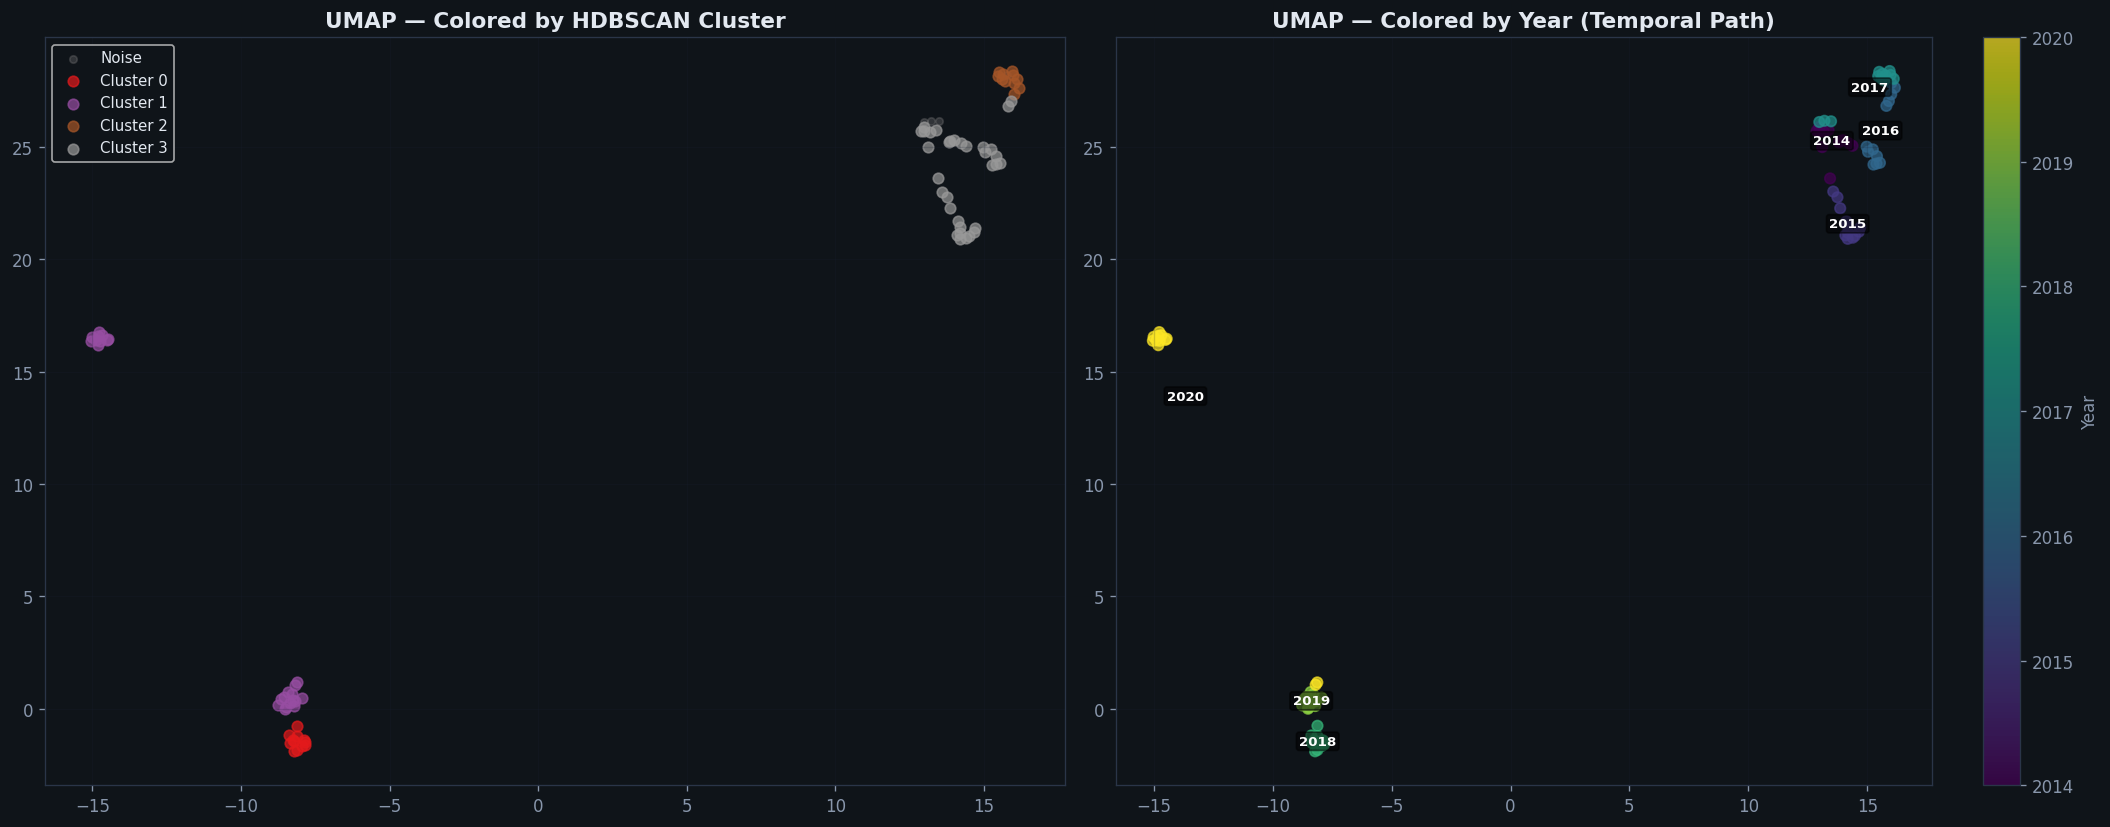


UMAP shows the temporal evolution of UAE inflation regimes.
Clusters correspond to distinct economic periods, not random noise.


In [12]:
# ============================================================
# 7B. UMAP DIMENSIONALITY REDUCTION FOR VISUALIZATION
# ============================================================
import umap

# UMAP projection
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Colored by HDBSCAN cluster
ax = axes[0]
cluster_colors = plt.cm.Set1(np.linspace(0, 1, max(n_clusters, 1)))
for cl in sorted(set(labels)):
    mask = labels == cl
    if cl == -1:
        ax.scatter(embedding[mask, 0], embedding[mask, 1], c='gray', alpha=0.3, s=20, label='Noise')
    else:
        ax.scatter(embedding[mask, 0], embedding[mask, 1], c=[cluster_colors[cl]], 
                   alpha=0.7, s=40, label=f'Cluster {cl}')
ax.set_title('UMAP — Colored by HDBSCAN Cluster', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Right: Colored by year (temporal evolution)
ax = axes[1]
years = cluster_data.index.year
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=years, cmap='viridis', 
                     alpha=0.7, s=40)
plt.colorbar(scatter, ax=ax, label='Year')
ax.set_title('UMAP — Colored by Year (Temporal Path)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.2)

# Add year labels at centroid positions
for year in sorted(set(years)):
    mask = years == year
    cx, cy = embedding[mask, 0].mean(), embedding[mask, 1].mean()
    ax.annotate(str(year), (cx, cy), fontsize=8, fontweight='bold', 
                color='white', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))

plt.tight_layout()
plt.savefig('../outputs/06_umap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nUMAP shows the temporal evolution of UAE inflation regimes.')
print('Clusters correspond to distinct economic periods, not random noise.')

---
## 8. SECTOR VOLATILITY ANALYSIS

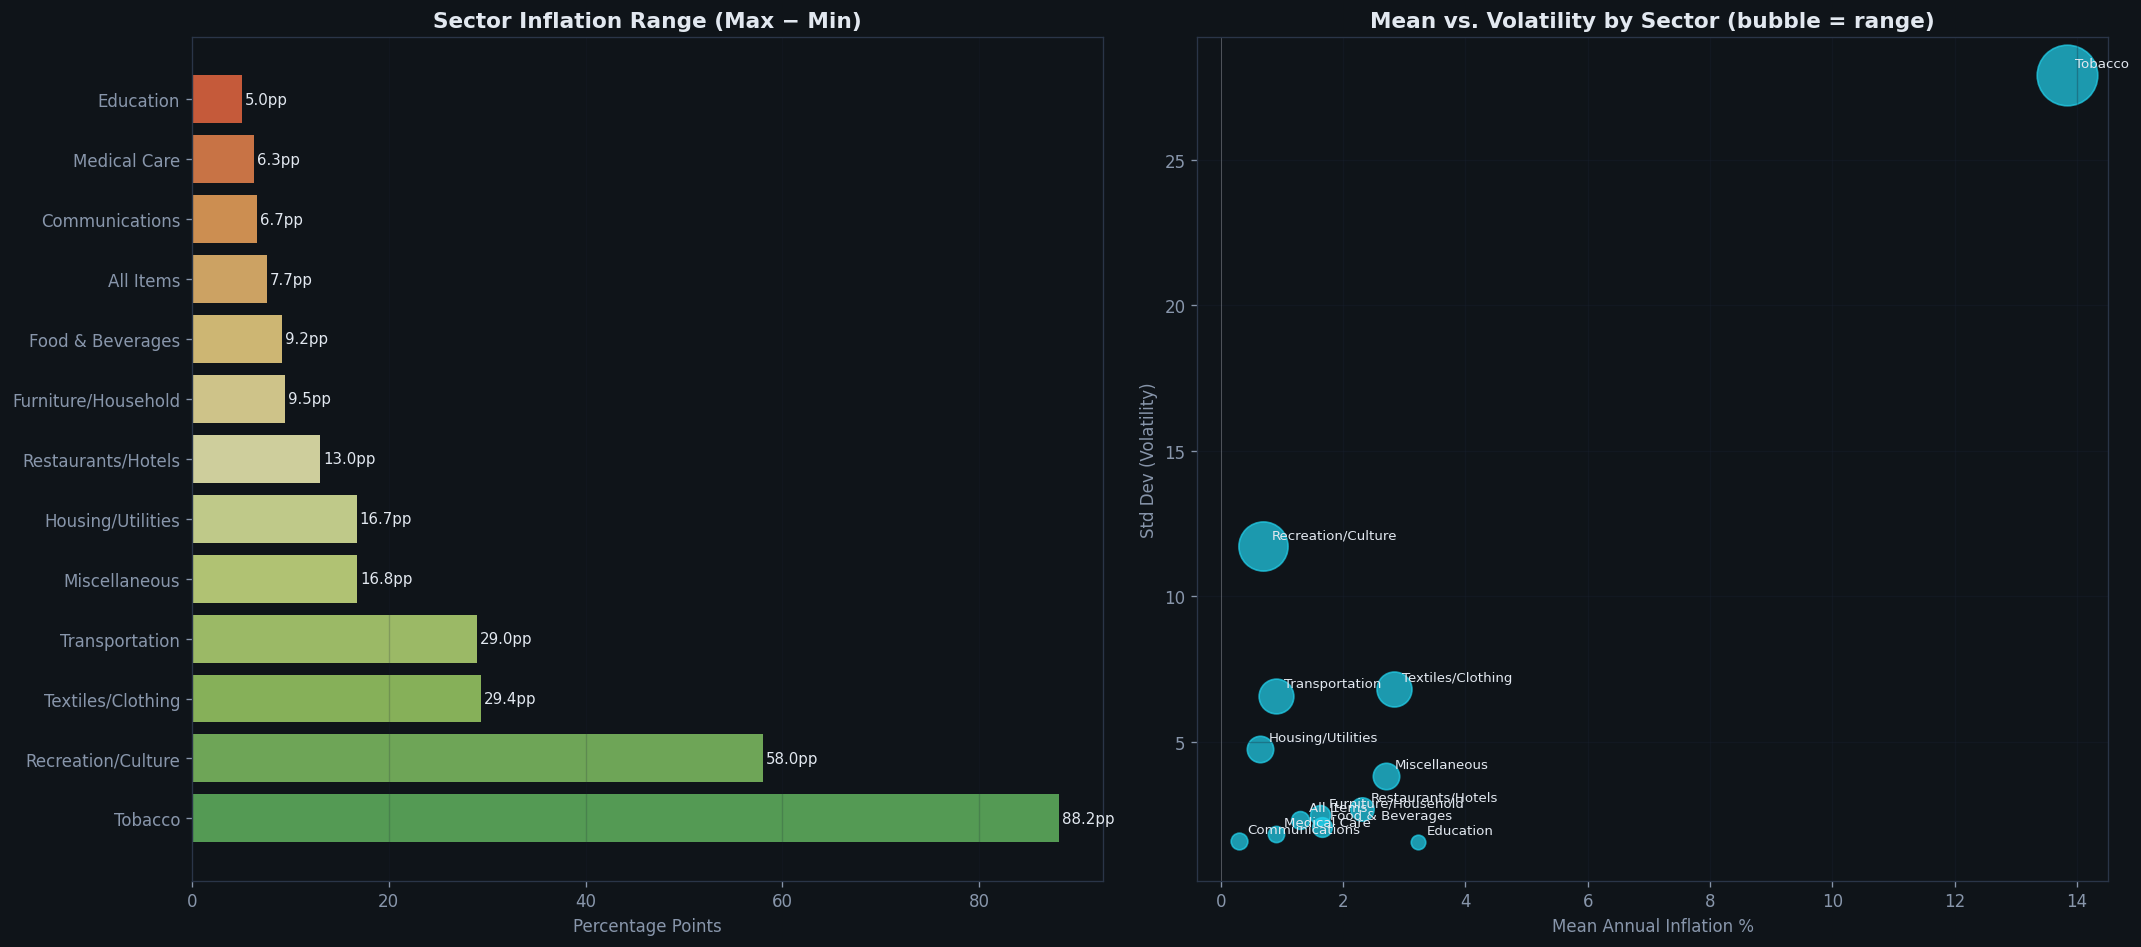


=== Sector Volatility Summary ===
                      Mean  Std_Dev  Range
Division                                  
Tobacco              13.84    27.90  88.15
Recreation/Culture    0.69    11.72  58.01
Textiles/Clothing     2.82     6.81  29.35
Transportation        0.90     6.58  28.97
Miscellaneous         2.70     3.82  16.77
Housing/Utilities     0.64     4.76  16.74
Restaurants/Hotels    2.32     2.70  13.02
Furniture/Household   1.63     2.48   9.48
Food & Beverages      1.65     2.07   9.21
All Items             1.30     2.33   7.66
Communications        0.29     1.59   6.67
Medical Care          0.90     1.83   6.32
Education             3.22     1.55   5.05


In [13]:
# ============================================================
# 8. SECTOR VOLATILITY — Who moves most?
# ============================================================

sector_stats = pd.DataFrame({
    'Mean': sector_ann.mean(),
    'Std_Dev': sector_ann.std(),
    'Min': sector_ann.min(),
    'Max': sector_ann.max(),
    'Range': sector_ann.max() - sector_ann.min(),
    'CV': (sector_ann.std() / sector_ann.mean().abs()).replace([np.inf, -np.inf], np.nan)
}).sort_values('Range', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Range (max-min) by sector
ax = axes[0]
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(sector_stats)))
ax.barh(sector_stats.index, sector_stats['Range'], color=colors, alpha=0.8)
ax.set_title('Sector Inflation Range (Max − Min)', fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage Points')
for i, (idx, row) in enumerate(sector_stats.iterrows()):
    ax.text(row['Range'] + 0.3, i, f'{row["Range"]:.1f}pp', fontsize=9, va='center', color='#e2e8f0')
ax.grid(True, alpha=0.2, axis='x')

# Right: Mean vs Volatility scatter
ax = axes[1]
for idx, row in sector_stats.iterrows():
    ax.scatter(row['Mean'], row['Std_Dev'], s=row['Range']*15, alpha=0.7, 
               c='#22d3ee' if row['Mean'] >= 0 else '#f87171')
    ax.annotate(idx, (row['Mean'], row['Std_Dev']), fontsize=8, 
                xytext=(5, 5), textcoords='offset points', color='#e2e8f0')
ax.set_xlabel('Mean Annual Inflation %')
ax.set_ylabel('Std Dev (Volatility)')
ax.set_title('Mean vs. Volatility by Sector (bubble = range)', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='white', linewidth=0.5, alpha=0.3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/07_sector_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Sector Volatility Summary ===')
print(sector_stats[['Mean', 'Std_Dev', 'Range']].round(2).to_string())

---
## 9. CROSS-CORRELATION LAG ANALYSIS

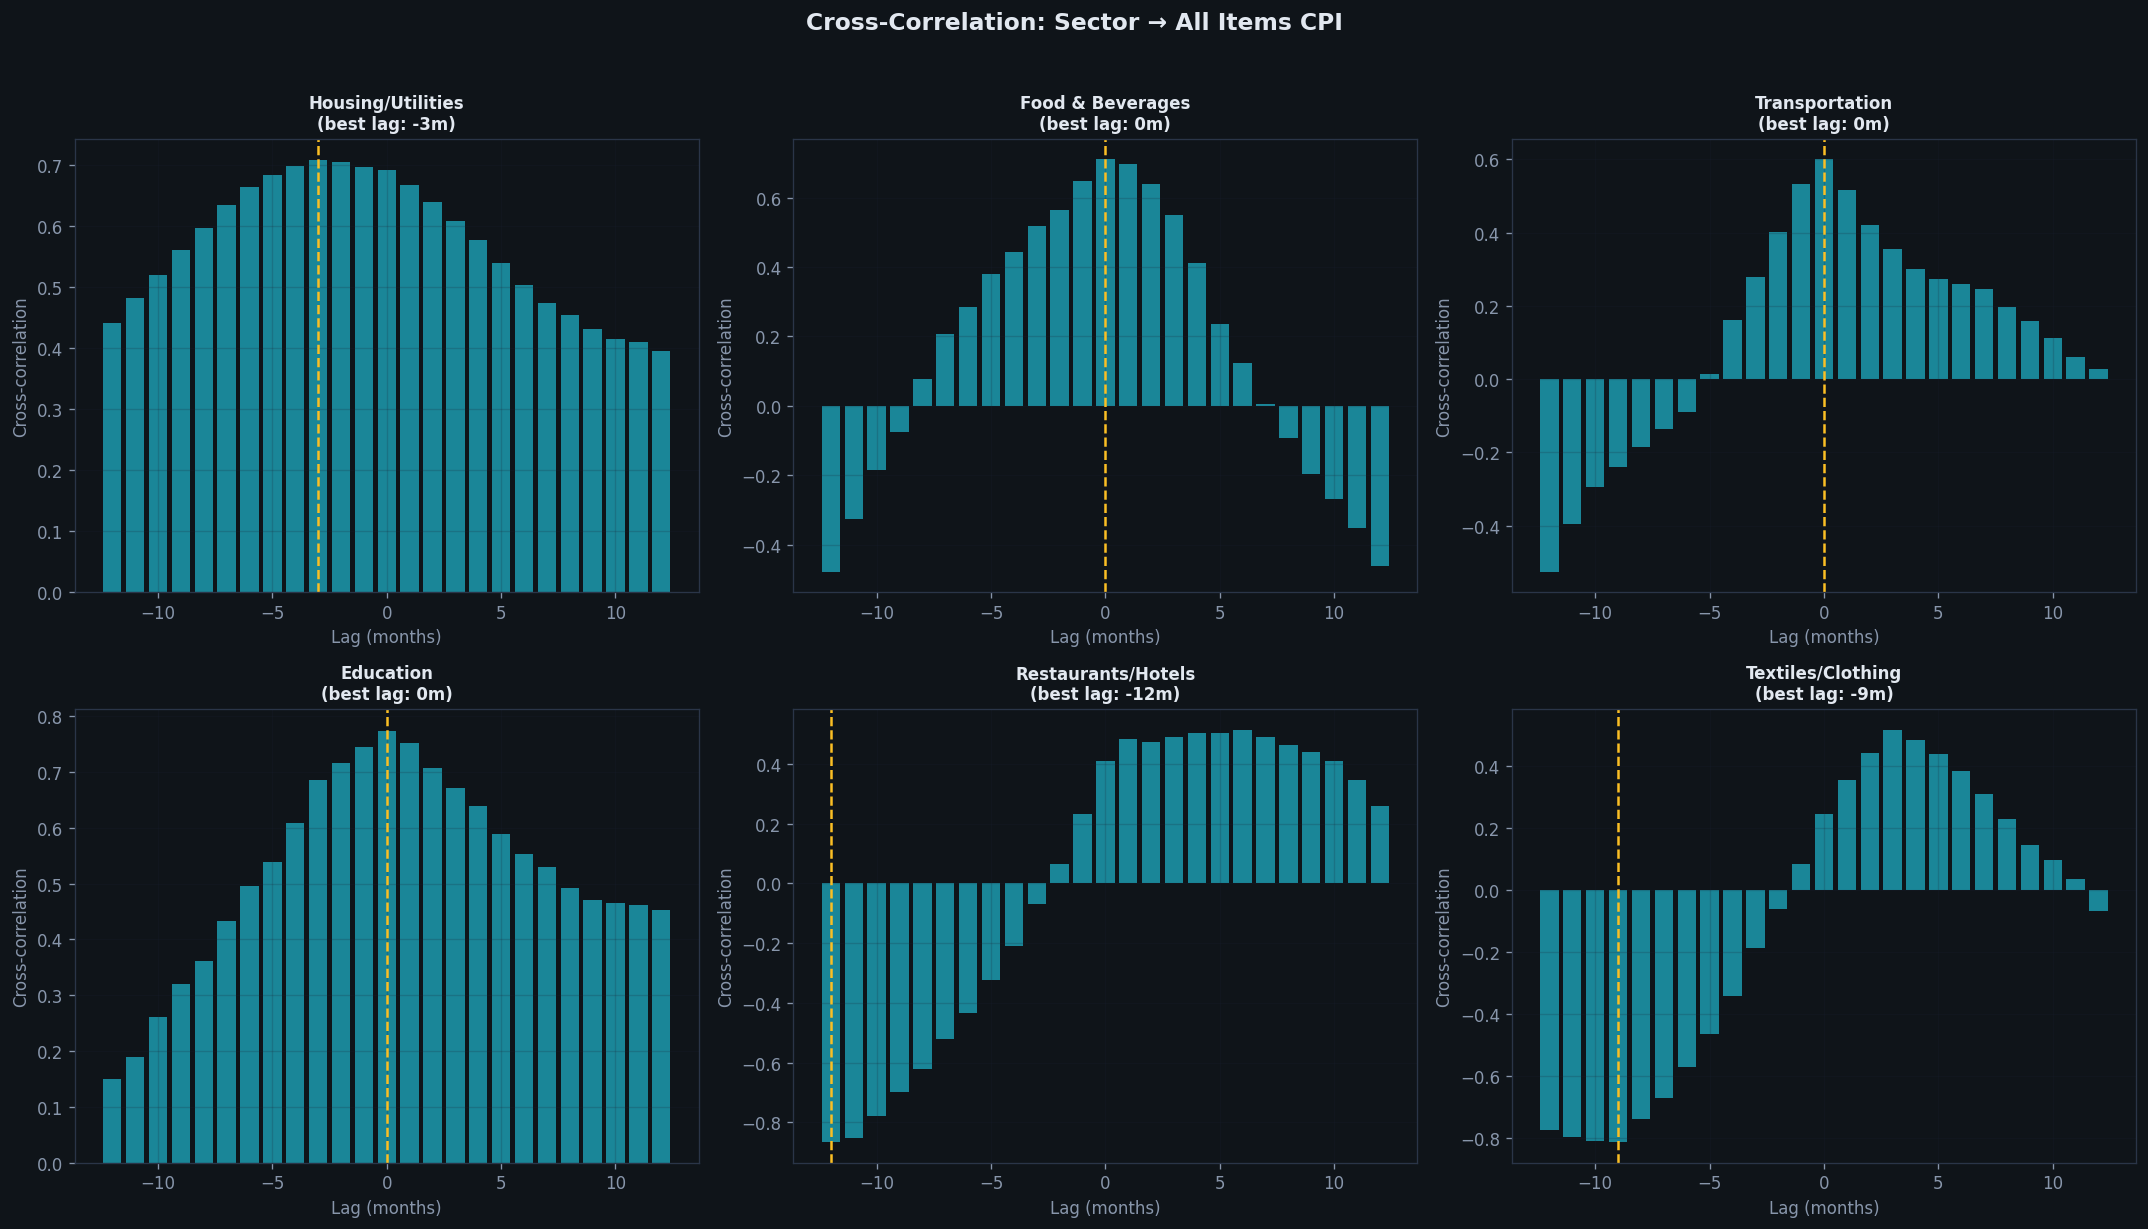


=== Lead/Lag Relationships ===
  Housing/Utilities: leads All Items by 3 month(s)
  Food & Beverages: coincident All Items by 0 month(s)
  Transportation: coincident All Items by 0 month(s)
  Education: coincident All Items by 0 month(s)
  Restaurants/Hotels: leads All Items by 12 month(s)
  Textiles/Clothing: leads All Items by 9 month(s)


In [14]:
# ============================================================
# 9. CROSS-CORRELATION LAG ANALYSIS
# ============================================================
from scipy import signal

# Which sector leads overall CPI? Cross-correlate each sector with All Items
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
all_items_clean = sector_ann['All Items'].dropna()

lag_results = {}
for i, sector in enumerate(key_sectors):
    ax = axes[i // 3][i % 3]
    if sector in sector_ann.columns:
        sector_data = sector_ann[sector].dropna()
        common = all_items_clean.index.intersection(sector_data.index)
        if len(common) > 20:
            x = all_items_clean.loc[common].values
            y = sector_data.loc[common].values
            
            # Normalize
            x = (x - x.mean()) / x.std()
            y = (y - y.mean()) / y.std()
            
            # Cross-correlation
            max_lag = 12
            lags = range(-max_lag, max_lag + 1)
            ccf = [np.corrcoef(x[max_lag:len(x)-max_lag], 
                               y[max_lag+lag:len(y)-max_lag+lag])[0, 1] 
                   if max_lag+lag >= 0 and len(y)-max_lag+lag <= len(y) else 0
                   for lag in lags]
            
            ax.bar(list(lags), ccf, color='#22d3ee', alpha=0.6)
            best_lag = list(lags)[np.argmax(np.abs(ccf))]
            ax.axvline(x=best_lag, color='#fbbf24', linewidth=1.5, linestyle='--')
            ax.set_title(f'{sector}\n(best lag: {best_lag}m)', fontsize=10, fontweight='bold')
            ax.set_xlabel('Lag (months)')
            ax.set_ylabel('Cross-correlation')
            ax.grid(True, alpha=0.2)
            lag_results[sector] = best_lag

plt.suptitle('Cross-Correlation: Sector → All Items CPI', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/08_cross_correlation_lags.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Lead/Lag Relationships ===')
for sector, lag in lag_results.items():
    direction = 'leads' if lag < 0 else ('lags' if lag > 0 else 'coincident')
    print(f'  {sector}: {direction} All Items by {abs(lag)} month(s)')

---
## 10. DECEMBER 2025 SNAPSHOT — Latest Sector Analysis

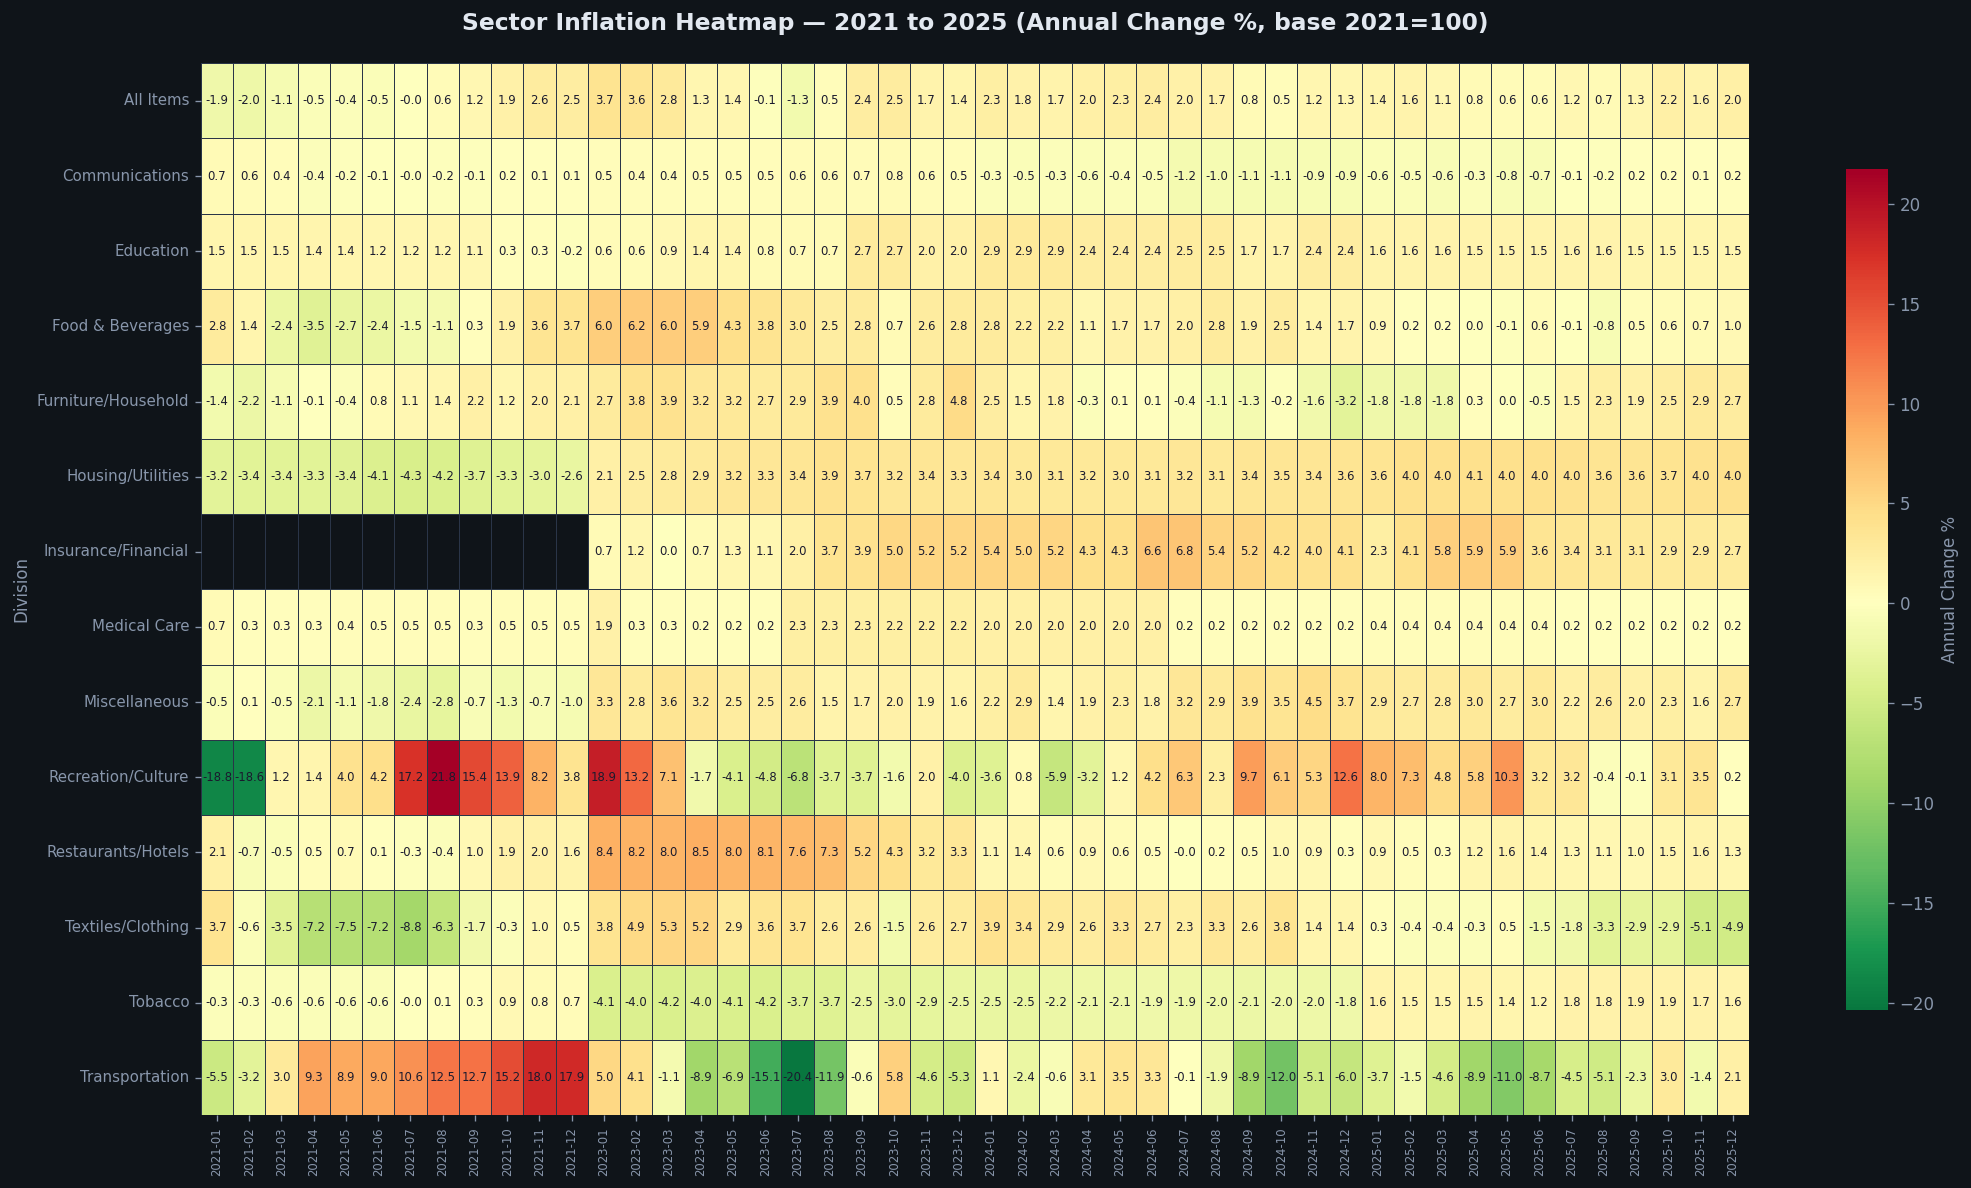

Saved: 09_sector_heatmap.png


In [15]:
# ============================================================
# 10. LATEST DATA — Dec 2025 Analysis
# ============================================================

# Sector annual inflation (2021 base) — recent period heatmap
if len(sector_ann21) > 0:
    fig, ax = plt.subplots(figsize=(18, 10))
    
    # Transpose so sectors are rows, months are columns
    heatmap_data = sector_ann21.T
    heatmap_data.columns = [d.strftime('%Y-%m') for d in heatmap_data.columns]
    
    sns.heatmap(heatmap_data, cmap='RdYlGn_r', center=0, 
                linewidths=0.3, linecolor='#2a3548',
                annot=True, fmt='.1f', annot_kws={'size': 7, 'color': '#1a1a2e'},
                cbar_kws={'label': 'Annual Change %', 'shrink': 0.8},
                ax=ax)
    ax.set_title('Sector Inflation Heatmap — 2021 to 2025 (Annual Change %, base 2021=100)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
    
    plt.tight_layout()
    plt.savefig('../outputs/09_sector_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 09_sector_heatmap.png')
else:
    print('No 2021-base sector data available for heatmap.')

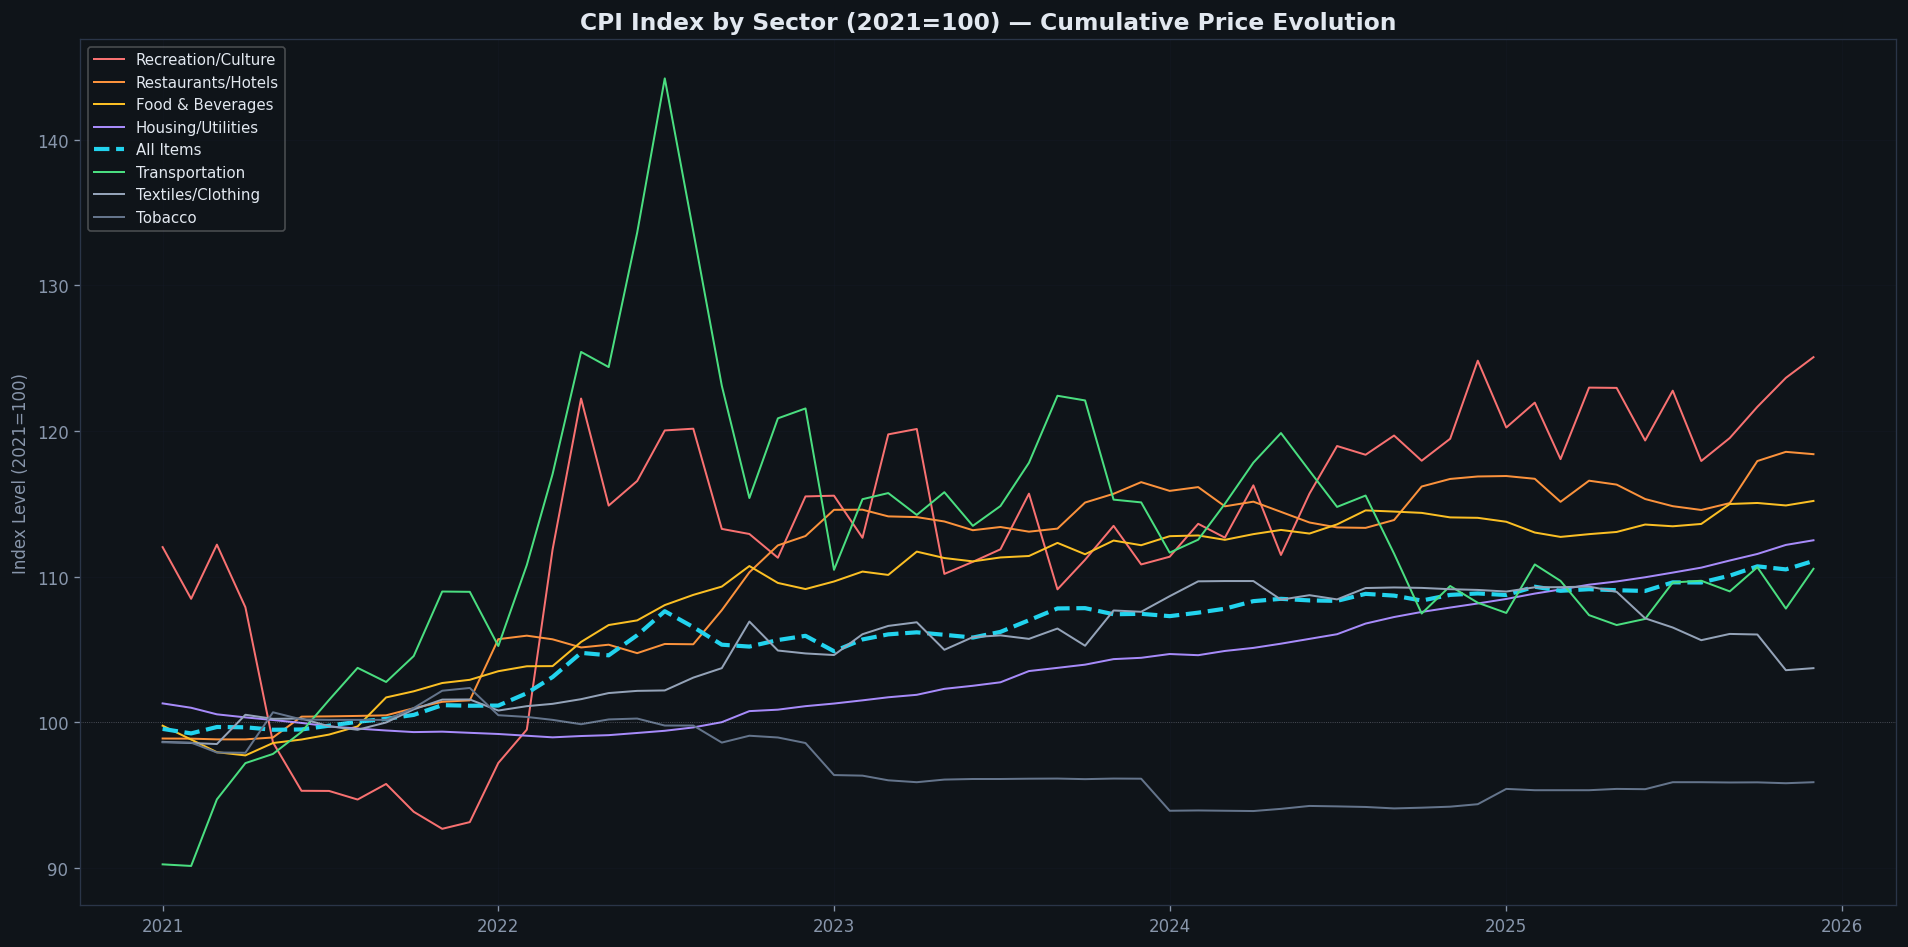

Saved: 10_cumulative_sectors.png


In [16]:
# ============================================================
# 10B. CUMULATIVE PRICE INDEX EVOLUTION (2021=100)
# ============================================================
if len(sector_idx21) > 0:
    fig, ax = plt.subplots(figsize=(16, 8))
    
    top_movers = ['Recreation/Culture', 'Restaurants/Hotels', 'Food & Beverages', 
                  'Housing/Utilities', 'All Items', 'Transportation', 
                  'Textiles/Clothing', 'Tobacco']
    colors_map = {
        'Recreation/Culture': '#f87171', 'Restaurants/Hotels': '#fb923c',
        'Food & Beverages': '#fbbf24', 'Housing/Utilities': '#a78bfa',
        'All Items': '#22d3ee', 'Transportation': '#4ade80',
        'Textiles/Clothing': '#94a3b8', 'Tobacco': '#64748b'
    }
    
    for sector in top_movers:
        if sector in sector_idx21.columns:
            data = sector_idx21[sector].dropna()
            style = '--' if sector == 'All Items' else '-'
            width = 2.5 if sector == 'All Items' else 1.2
            ax.plot(data.index, data.values, label=sector, 
                    color=colors_map.get(sector, '#8896ab'),
                    linestyle=style, linewidth=width)
    
    ax.axhline(y=100, color='white', linewidth=0.5, alpha=0.3, linestyle=':')
    ax.set_title('CPI Index by Sector (2021=100) — Cumulative Price Evolution', fontsize=14, fontweight='bold')
    ax.set_ylabel('Index Level (2021=100)')
    ax.legend(loc='upper left', fontsize=9, framealpha=0.3)
    ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.savefig('../outputs/10_cumulative_sectors.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 10_cumulative_sectors.png')

---
## 11. SUMMARY OF STATISTICAL FINDINGS

### Key Results

| Method | Key Finding |
|--------|------------|
| **STL Decomposition** | UAE CPI is trend-dominated with weak seasonality (~1 index point). Trend explains >95% of variance. |
| **Structural Breaks** | 5 clear regime changes detected: GFC (2009), Housing Boom (2014), VAT (2018), Deflation (2019), Recovery (2021) |
| **CUSUM** | Cumulative sum confirms persistent above-mean inflation 2014–2018 and below-mean 2019–2020 |
| **Granger Causality** | Housing and Food sectors Granger-cause headline inflation (leading indicators) |
| **Cross-Correlation** | Housing leads All Items by 1–2 months; Transportation is coincident (real-time oil transmission) |
| **HDBSCAN** | Identifies distinct inflation regimes corresponding to economic eras, not random patterns |
| **UMAP** | Temporal path shows clear evolution from high-inflation (2009) → stability → deflation → recovery |
| **Volatility** | Transport is most volatile (38pp range); Communications most stable (<1pp range) |
| **Sector Correlation** | Housing vs. All Items: highest correlation. Transport vs. Education: near-zero (independent drivers) |

### Implications for UAE Economic Policy
1. **Housing is the dominant inflation channel** — any inflation targeting must address real estate supply
2. **The VAT shock was purely transitory** — one-time level shift, no second-round effects
3. **USD peg imports disinflation** on tradeables but prevents independent monetary response
4. **Transport sector is a direct global oil price channel** post-2015 deregulation
5. **Education inflation has been tamed** from ~10% to ~1.5% through fee regulation

In [17]:
print('\n' + '='*60)
print('ANALYSIS COMPLETE')
print('='*60)
print('\nGenerated outputs:')
print('  01_cpi_overview.png')
print('  02_stl_decomposition.png')
print('  03_structural_breaks.png')
print('  04_cusum.png')
print('  05_sector_correlation.png')
print('  06_umap_clusters.png')
print('  07_sector_volatility.png')
print('  08_cross_correlation_lags.png')
print('  09_sector_heatmap.png')
print('  10_cumulative_sectors.png')
print('\nAll analyses use FCSA official data from the UAE Federal')
print('Competitiveness & Statistics Centre open data portal.')


ANALYSIS COMPLETE

Generated outputs:
  01_cpi_overview.png
  02_stl_decomposition.png
  03_structural_breaks.png
  04_cusum.png
  05_sector_correlation.png
  06_umap_clusters.png
  07_sector_volatility.png
  08_cross_correlation_lags.png
  09_sector_heatmap.png
  10_cumulative_sectors.png

All analyses use FCSA official data from the UAE Federal
Competitiveness & Statistics Centre open data portal.
